In [28]:
#Import Libraries and read data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

IQMfname='/data/projects/srndna-data/derivatives/mriqc/group_bold.tsv'
bidsfname='/data/projects/srndna-data/bids/participants.tsv'

IQM_df=pd.read_csv(IQMfname,sep='\t')
subs_df=pd.read_csv(bidsfname,sep='\t')

In [29]:
IQM_df[['participant_id','task','run','mode']]=IQM_df['bids_name'].str.split('_',expand=True)

In [35]:
full_df=pd.merge(IQM_df,subs_df,on='participant_id')
full_df['group']=full_df['age']>60
full_df['group'] = full_df['group'].map({True:'Older', False:'Younger'})
full_df.columns

Index(['bids_name', 'aor', 'aqi', 'dummy_trs', 'dvars_nstd', 'dvars_std',
       'dvars_vstd', 'efc', 'fber', 'fd_mean', 'fd_num', 'fd_perc', 'fwhm_avg',
       'fwhm_x', 'fwhm_y', 'fwhm_z', 'gcor', 'gsr_x', 'gsr_y', 'size_t',
       'size_x', 'size_y', 'size_z', 'snr', 'spacing_tr', 'spacing_x',
       'spacing_y', 'spacing_z', 'summary_bg_k', 'summary_bg_mad',
       'summary_bg_mean', 'summary_bg_median', 'summary_bg_n',
       'summary_bg_p05', 'summary_bg_p95', 'summary_bg_stdv', 'summary_fg_k',
       'summary_fg_mad', 'summary_fg_mean', 'summary_fg_median',
       'summary_fg_n', 'summary_fg_p05', 'summary_fg_p95', 'summary_fg_stdv',
       'tsnr', 'participant_id', 'task', 'run', 'mode', 'age', 'sex', 'group'],
      dtype='object')

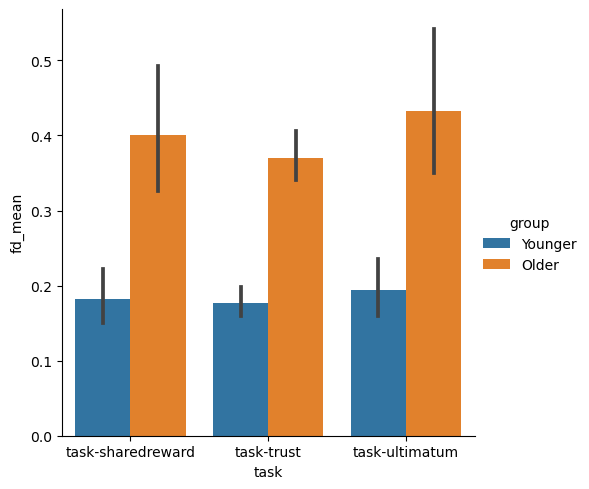

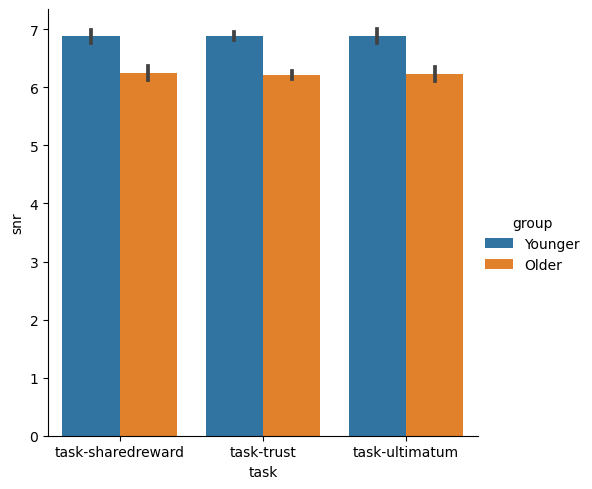

In [41]:
sns.catplot(x='task',y='fd_mean',hue='group',data=full_df,kind='bar')
plt.savefig('../derivatives/figures/FDMean_byGroup.svg')
plt.show()
sns.catplot(x='task',y='snr',hue='group',data=full_df,kind='bar')
plt.savefig('../derivatives/figures/tSNR_byGroup.svg')
plt.show()

In [39]:
import os
os.mkdir('../derivatives/figures')